In [1]:
library(dplyr)
library(ggplot2)
library(patchwork)
library(openxlsx)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
Classification <- 'Classification_L4'
anndata_path <- '/home/liyanguo/MyImmuCell/06_Finnal_raw_count/pseudo_adata_Classification_L4/'
output_root <- paste0('/home/liyanguo/MyImmuCell/08_supp_outputs/residual_cor/')
dir.create(output_root, recursive = TRUE, showWarnings = FALSE)

# Multimodal integration delineates immune baseline deviation

In [3]:
frac_clinicl_table <- "/home/liyanguo/MyImmuCell/06_Finnal_raw_count/Classification_L4_donor_counts_frac_clinicl_table.xlsx"
levels_group <- c('2_9','10_19','20_29','30_39','40_49','50_59','60_69','70_79','80_89','90_')

In [4]:
# --- 1. 数据准备 ---
all_dat = read.csv("../13_Multimodal/all_data.csv", row.names=1, check.names=F)
meta_all <- read.xlsx(frac_clinicl_table, rowNames=TRUE, check.names=F)
meta_all$Ten_year_intervals <- gsub('[-]|[+]','_', meta_all$Ten_year_intervals)
meta_all = meta_all %>%
  dplyr::select(DonorID, ClinicalID, Batch, Gender, Pregnancy, Sampling.time, Ten_year_intervals) %>%
  dplyr::filter(Pregnancy == 'NO', Sampling.time == 'Morning')

all_dat$Ten_year_intervals <- meta_all$Ten_year_intervals[
  match(rownames(all_dat), meta_all$ClinicalID)
]

all_dat$Ten_year_intervals = factor(all_dat$Ten_year_intervals,levels = levels_group)

In [5]:
#增加异常值标签
drop_id = read.csv('../13_Multimodal/After_drop/cand_drop_ids.csv')
drop_id = subset(drop_id, drop_id$Flag=='True')
all_dat$tag = ifelse(rownames(all_dat) %in% drop_id$ClinicalID, 'Drop', 'Pass')

In [6]:
#增加重要性列表
top_n_feature = 20
shap = read.csv("../13_Multimodal/shap_importance.csv", row.names=1)[1:top_n_feature,]
all_dat_core = all_dat[, c(shap$feature, 'Age_in_Years', 'tag', 'Ten_year_intervals')]
all_dat_core <- na.omit(all_dat_core)

In [7]:
#读取多模态预测年龄和残差

In [8]:
predicted_age <- read.csv("../13_Multimodal/Residual.csv", row.names=1)

In [9]:
predicted_age$Age_gaps = ifelse(predicted_age$RobustZ>1.5,'Positive offsets',ifelse(predicted_age$RobustZ< -1.5,'Negative offsets','Concordance'))

In [10]:
predicted_age$Ten_year_intervals <- meta_all$Ten_year_intervals[
  match(rownames(predicted_age), meta_all$ClinicalID)
]

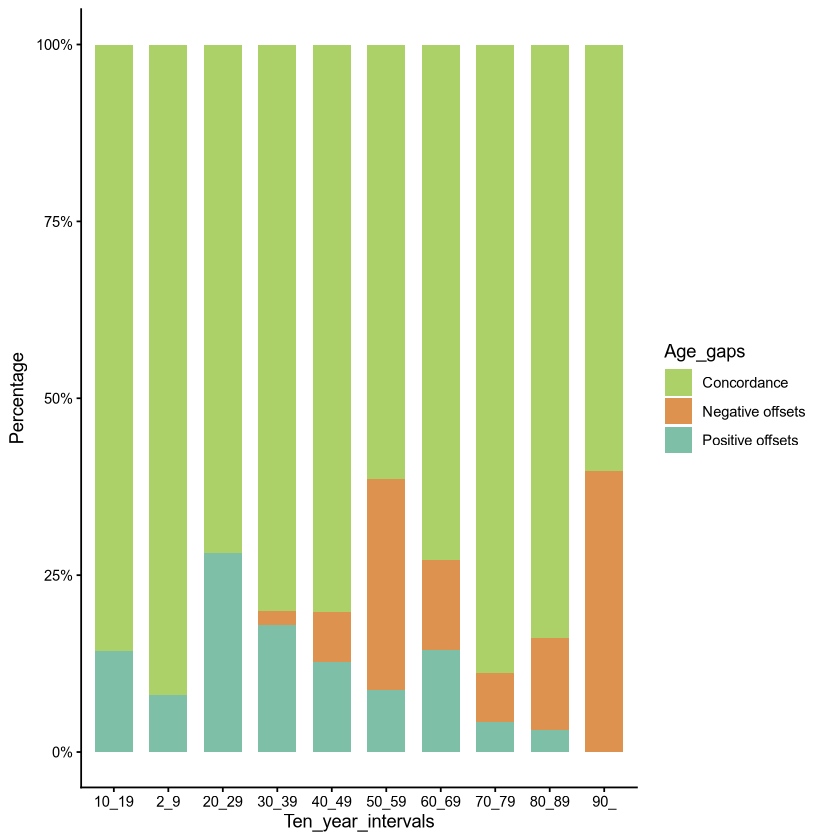

In [11]:
p = ggplot(predicted_age, aes(x = Ten_year_intervals, fill = Age_gaps)) +
  geom_bar(position = "fill", width = 0.7) +
  scale_y_continuous(labels = scales::percent_format()) +
  labs(y = "Percentage") + scale_fill_manual(values = c('#ACD168','#DD934F','#7DBFA7')) +
  theme_classic()
p
ggsave('../13_Multimodal/age_gap.pdf',width=6,height = 6)

In [12]:
#确保样本ID匹配
common_samples <- intersect(rownames(all_dat_core), rownames(predicted_age))
cat("共同样本数:", length(common_samples), "\n")

共同样本数: 914 


In [13]:
predicted_age <- predicted_age[common_samples, , drop=FALSE]

In [14]:
all_dat_core <- all_dat_core[common_samples, , drop=FALSE]

# --- 3. 计算免疫偏移指标 ---

In [15]:
table(all_dat_core$tag,all_dat_core$Ten_year_intervals)

      
       2_9 10_19 20_29 30_39 40_49 50_59 60_69 70_79 80_89 90_
  Drop   3     6     9    15    12    19    24    12    13  27
  Pass  47    49    50    83    72    38    99   131   149  56

In [16]:
baseline_age_cutoff_low <- 0
baseline_age_cutoff_high <- 10
baseline_samples <- all_dat_core %>% 
  filter(tag == 'Pass', baseline_age_cutoff_low <= Age_in_Years & Age_in_Years < baseline_age_cutoff_high)
cat("Base line samples:", dim(baseline_samples), "\n")

Base line samples: 47 23 


In [17]:
baseline_features <- baseline_samples %>% 
  select(all_of(shap$feature))

In [18]:
# 基线统计量
baseline_center <- colMeans(baseline_features, na.rm=TRUE)
baseline_sd <- apply(baseline_features, 2, sd, na.rm=TRUE)
baseline_q025 <- apply(baseline_features, 2, quantile, 0.025, na.rm=TRUE)
baseline_q975 <- apply(baseline_features, 2, quantile, 0.975, na.rm=TRUE)

In [19]:
# 异常负担
test_features <- all_dat_core %>% select(all_of(shap$feature))
out_of_range <- sweep(test_features, 2, baseline_q025, "<") |
                sweep(test_features, 2, baseline_q975, ">")
all_dat_core$abnormal_burden <- rowSums(out_of_range)

In [35]:
all_dat_core$Residual <- predicted_age$Residual[
  match(rownames(all_dat_core), rownames(predicted_age))
]
all_dat_core$RobustZ <- predicted_age$RobustZ[
  match(rownames(all_dat_core), rownames(predicted_age))
]
all_dat_core$Predicted_age <- predicted_age$Predicted_age[
  match(rownames(all_dat_core), rownames(predicted_age))
]

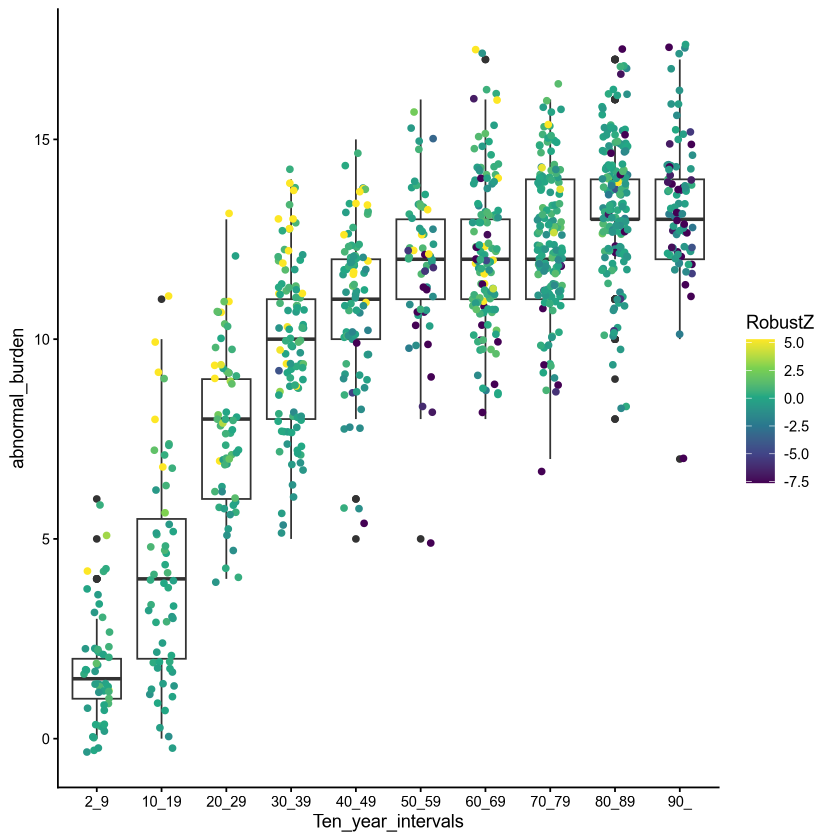

In [21]:
ggplot(all_dat_core,aes(y = abnormal_burden, x = Ten_year_intervals))+
    geom_boxplot()+geom_jitter(width = 0.2,aes(color=RobustZ))+
    scale_color_viridis_c(
        limits = quantile(all_dat_core$RobustZ, c(0.05, 0.95)),
        oob = scales::squish) +
    theme_classic()

## 马氏距离

In [22]:
all_dat_md = all_dat_core %>% select(-tag,-Ten_year_intervals,-Age_in_Years,-abnormal_burden,-RobustZ)

In [23]:
baseline_center <- colMeans(baseline_features, na.rm = TRUE)
scale_ref <- (baseline_q975 - baseline_q025) / 2

Z <- sweep(all_dat_md, 2, baseline_center, "-")
Z <- sweep(Z, 2, scale_ref, "/")

In [24]:
Z[abs(Z) <= 1] <- 0
Z[abs(Z) > 1] <- abs(Z[abs(Z) > 1]) - 1

Z_ref <- Z[which(rownames(all_dat_core) %in% rownames(baseline_samples)), ]

library(corpcor)
cov_ref <- cov.shrink(Z_ref, lambda = "auto")
kappa(cov_ref)

mahal_dist <- mahalanobis(
  Z,
  center = rep(0, ncol(Z)),
  cov = cov_ref
)

Estimating optimal shrinkage intensity lambda.var (variance vector): 0.9719 

Specified shrinkage intensity lambda (correlation matrix): 1 



[1] 1.762207

In [25]:
# ref <- baseline_samples %>% select(-Age_in_Years,-tag,-Ten_year_intervals)
# baseline_center <- colMeans(ref, na.rm = TRUE)
# library(corpcor)
# cov_ref <- cov.shrink(ref, lambda = "auto")
# kappa(cov_ref)
# mahal_dist <- mahalanobis(
#   all_dat_md,
#   center = baseline_center,
#   cov = cov_ref
# )

In [26]:
all_dat_core$mahal_dist <- mahal_dist
all_dat_core$mahal_dist_sqrt <- sqrt(mahal_dist)

Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 10 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 9 rows containing missing values or values outside the scale range
(`geom_point()`).”


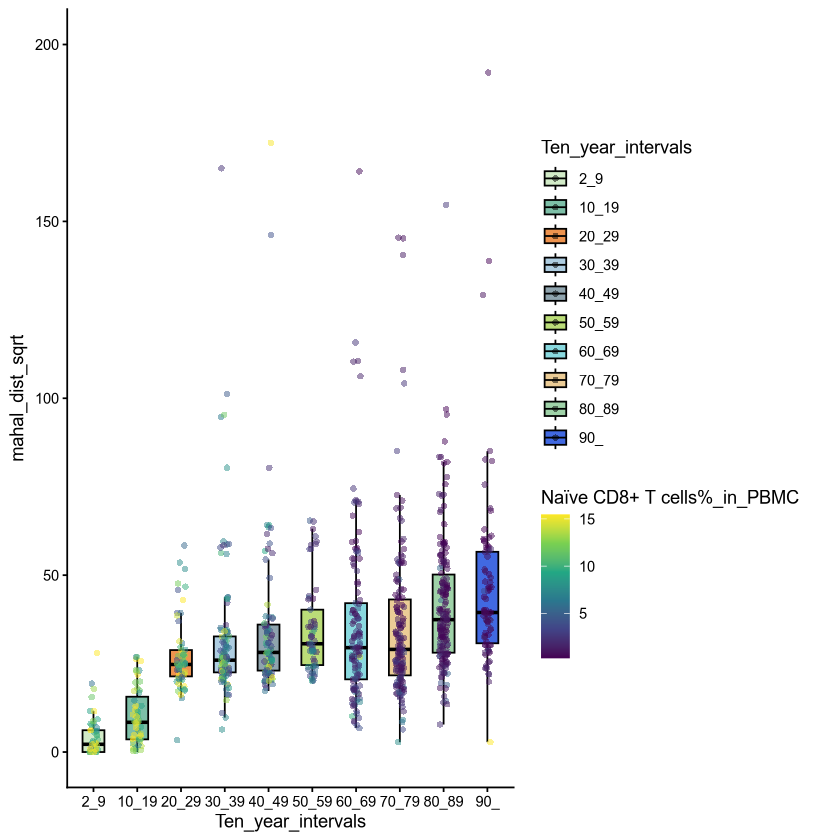

Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 9 rows containing missing values or values outside the scale range
(`geom_point()`).”


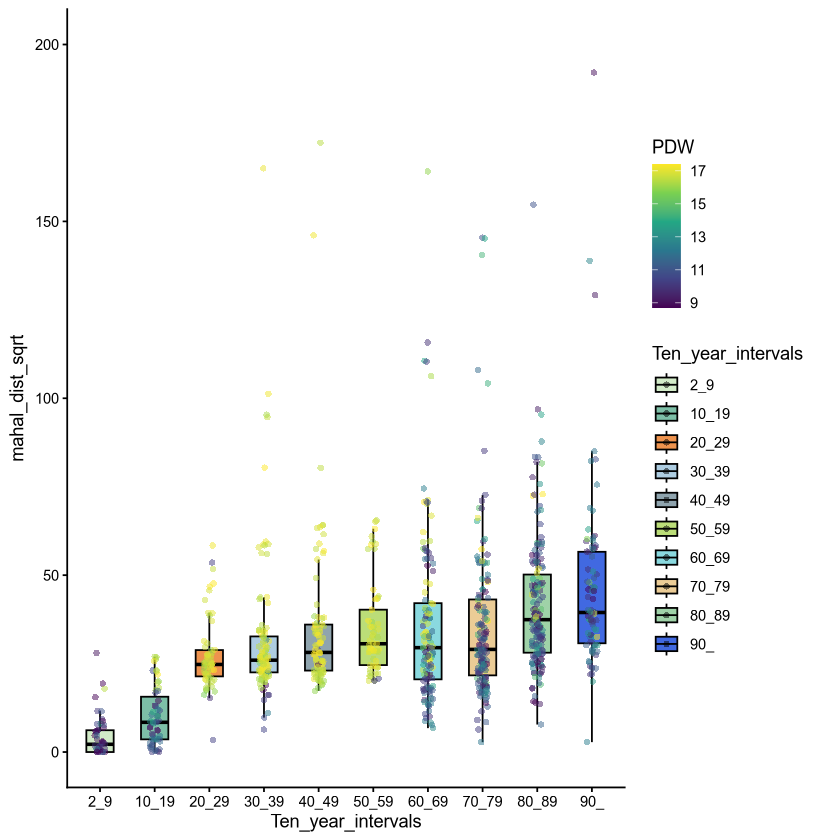

Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 12 rows containing missing values or values outside the scale range
(`geom_point()`).”


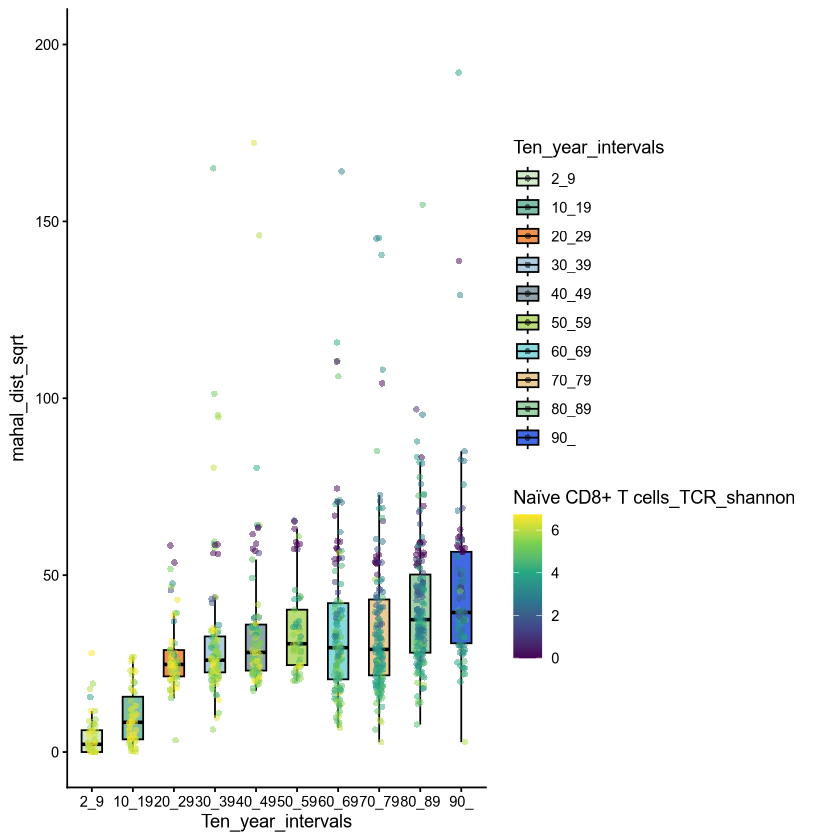

Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range
(`geom_point()`).”


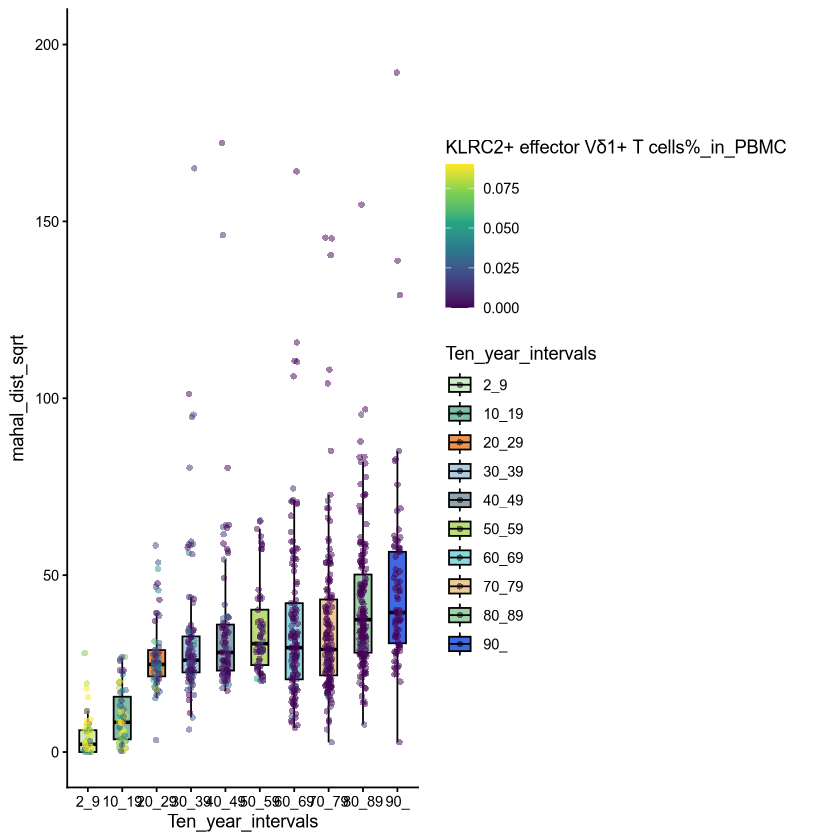

Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 8 rows containing missing values or values outside the scale range
(`geom_point()`).”


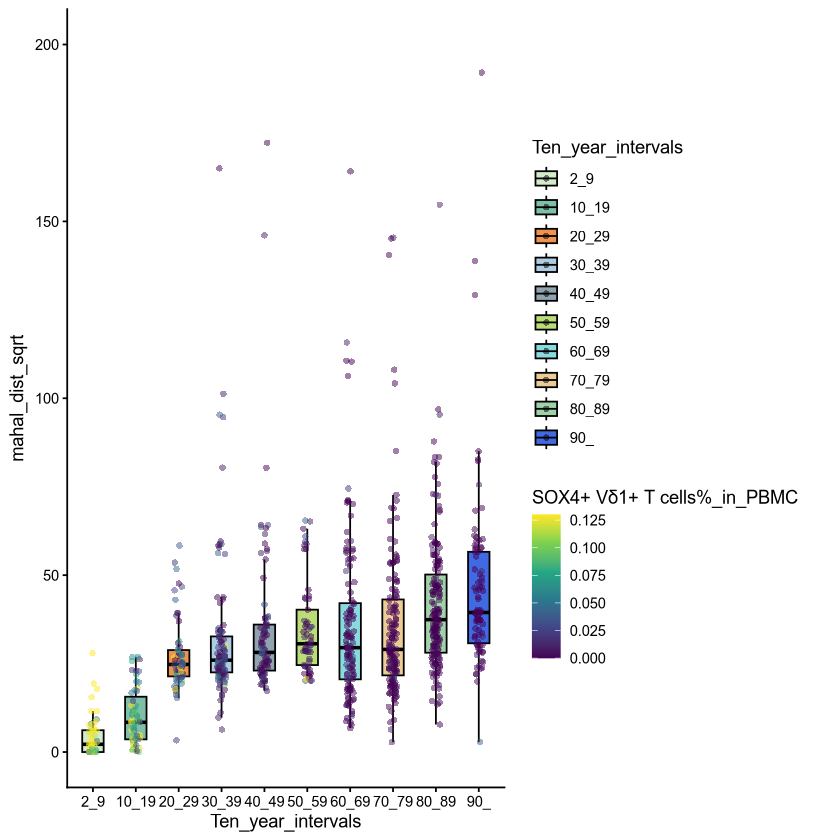

Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 6 rows containing missing values or values outside the scale range
(`geom_point()`).”


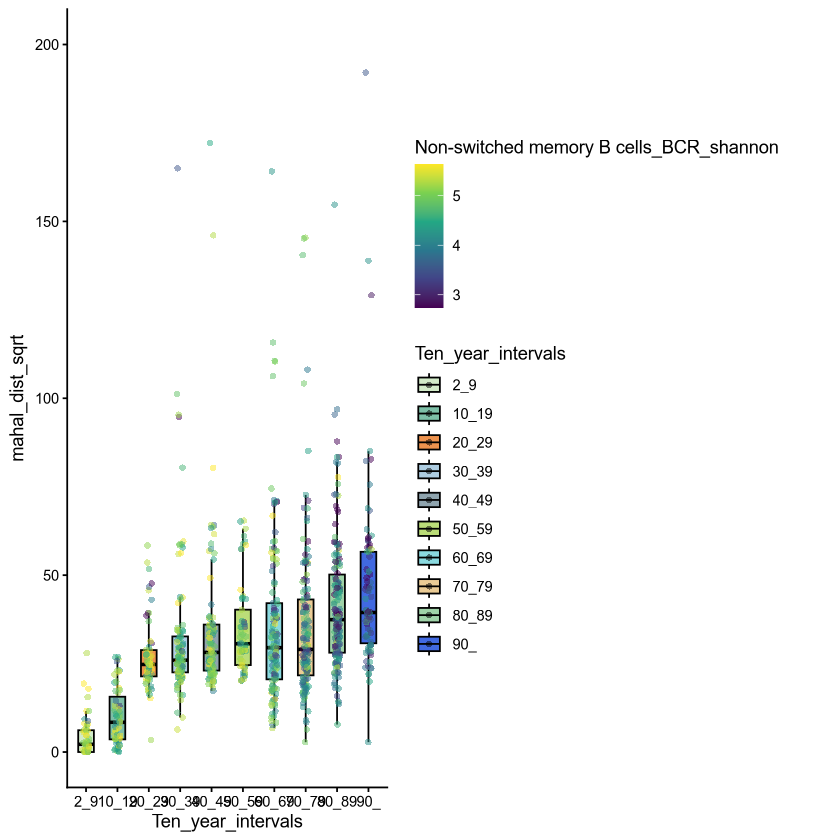

Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 9 rows containing missing values or values outside the scale range
(`geom_point()`).”


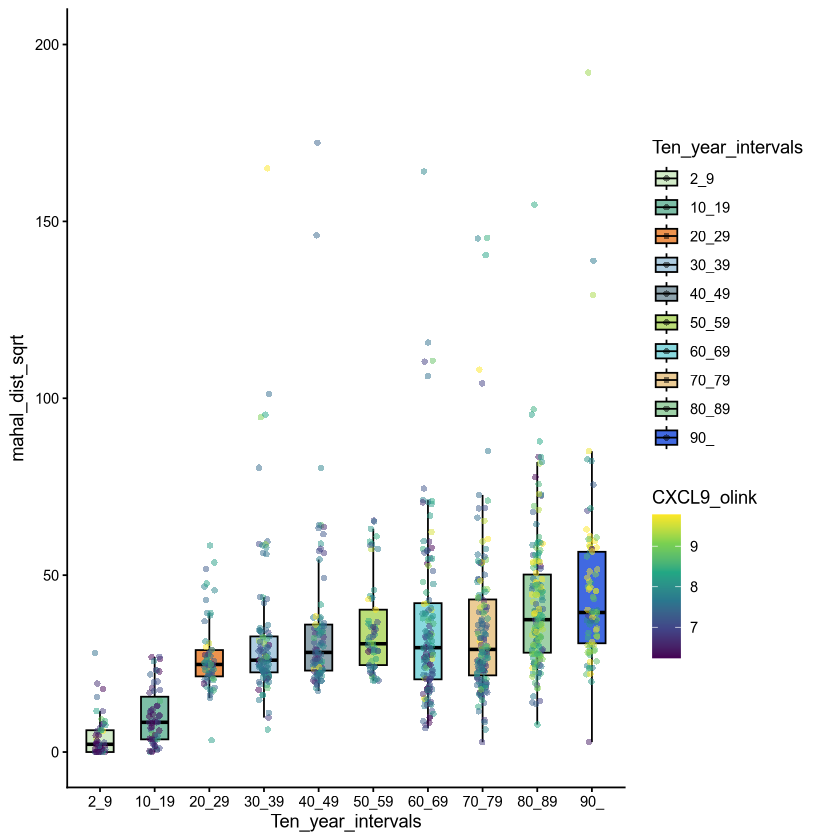

Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 10 rows containing missing values or values outside the scale range
(`geom_point()`).”


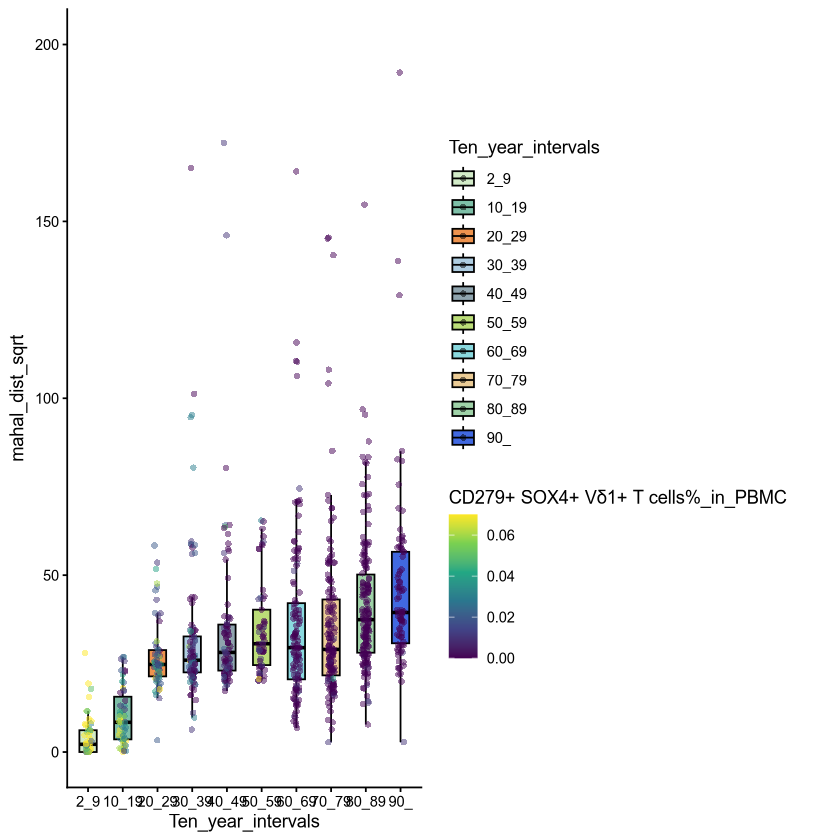

Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 7 rows containing missing values or values outside the scale range
(`geom_point()`).”


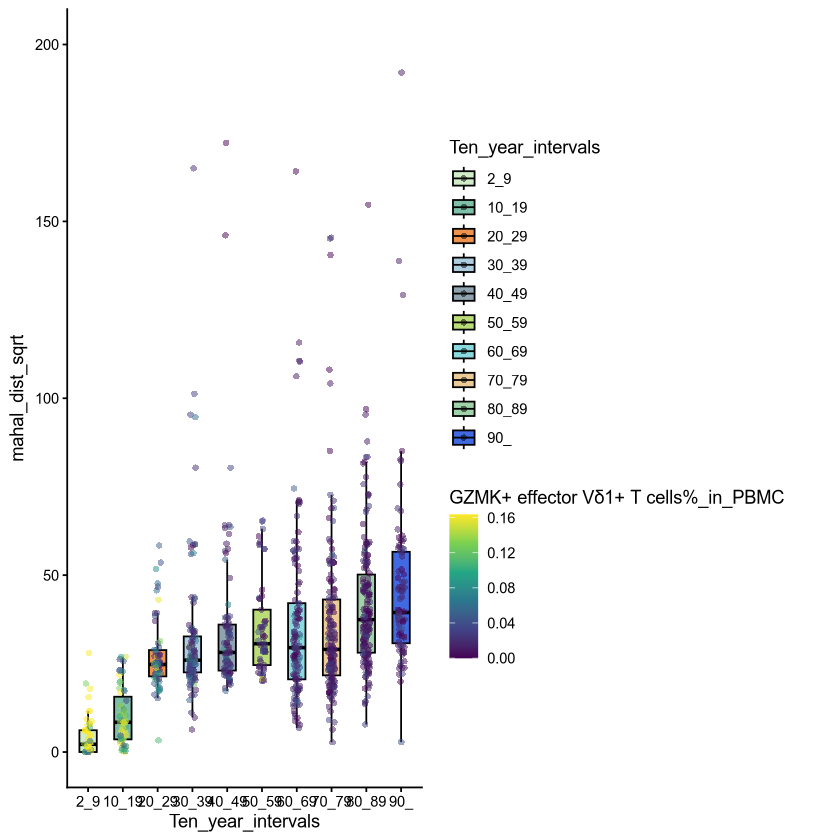

Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 10 rows containing missing values or values outside the scale range
(`geom_point()`).”


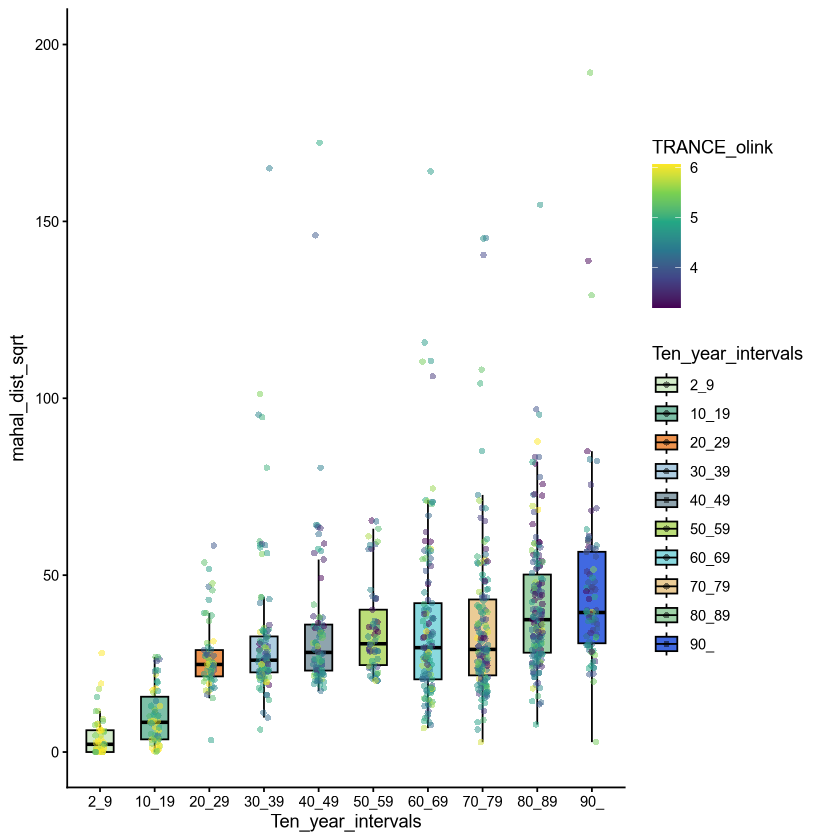

Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 10 rows containing missing values or values outside the scale range
(`geom_point()`).”


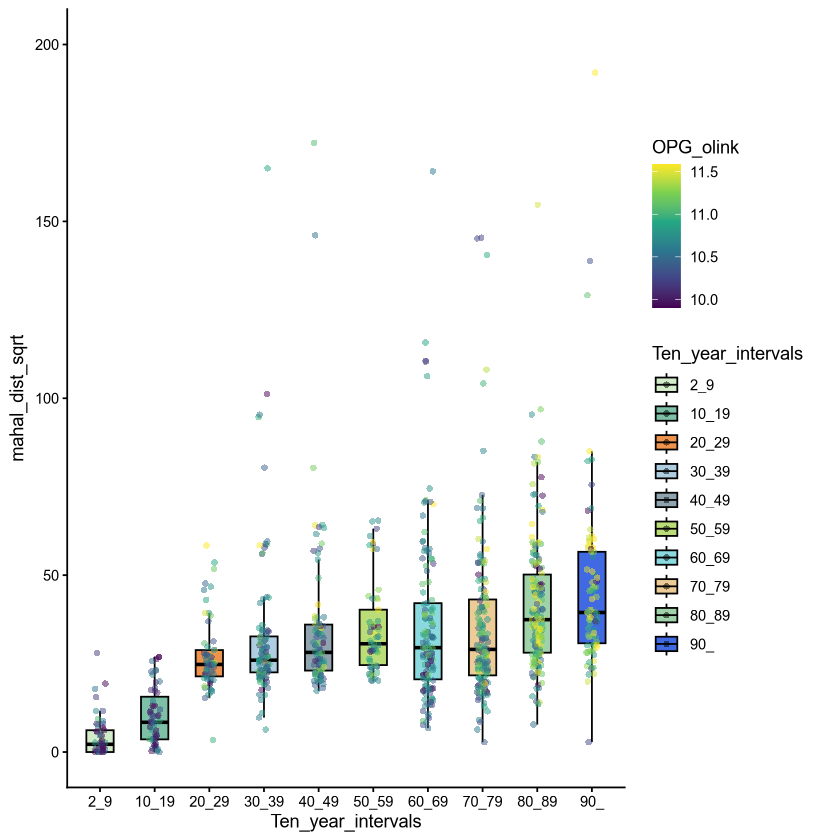

Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 7 rows containing missing values or values outside the scale range
(`geom_point()`).”


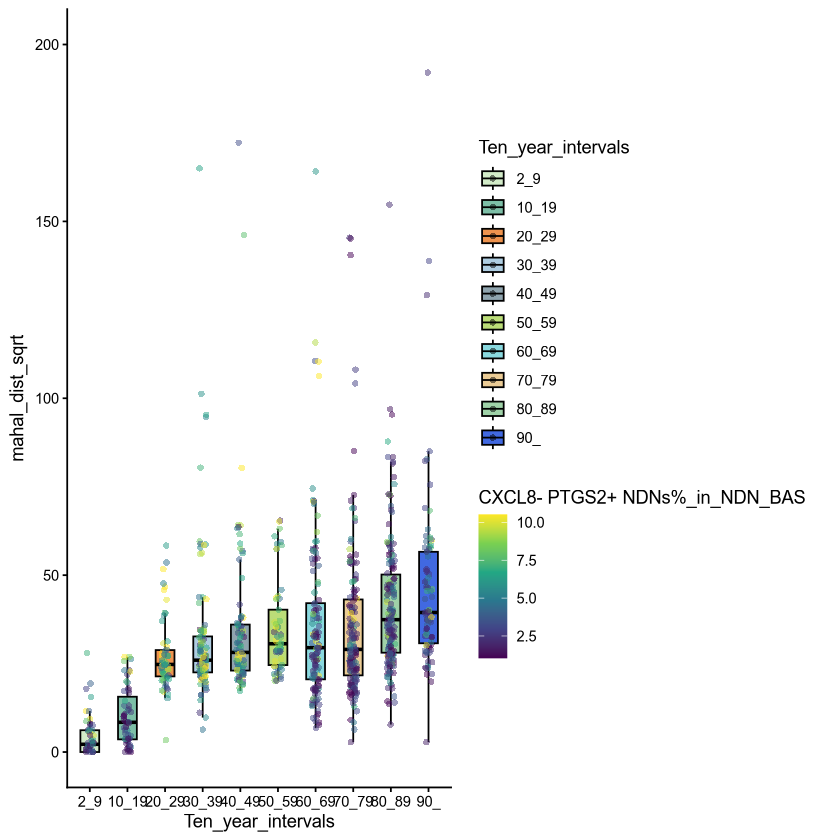

Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 11 rows containing missing values or values outside the scale range
(`geom_point()`).”


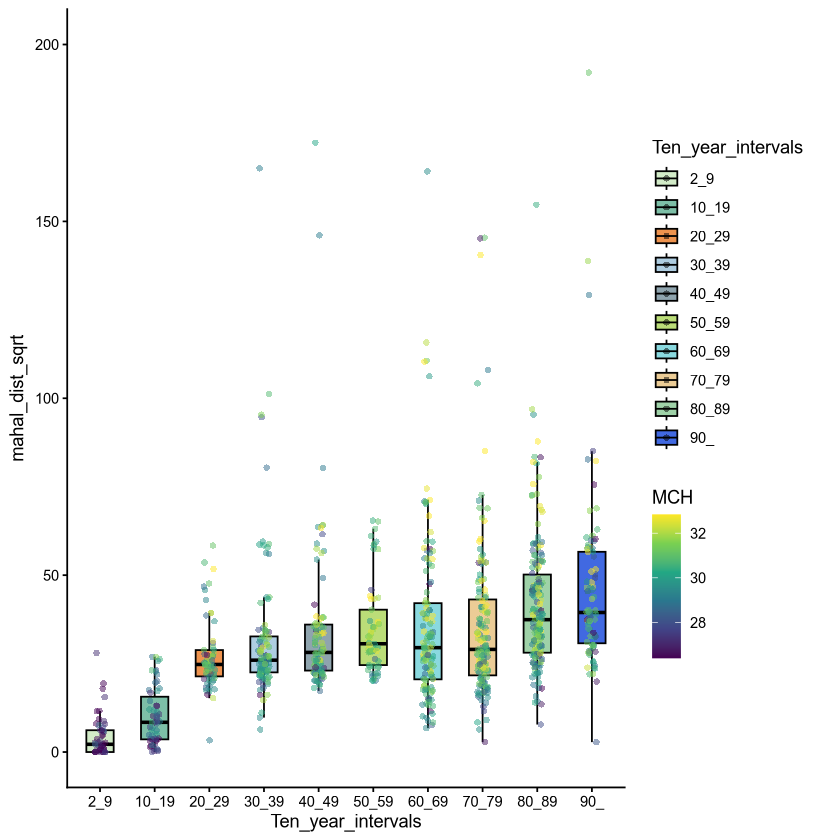

Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 9 rows containing missing values or values outside the scale range
(`geom_point()`).”


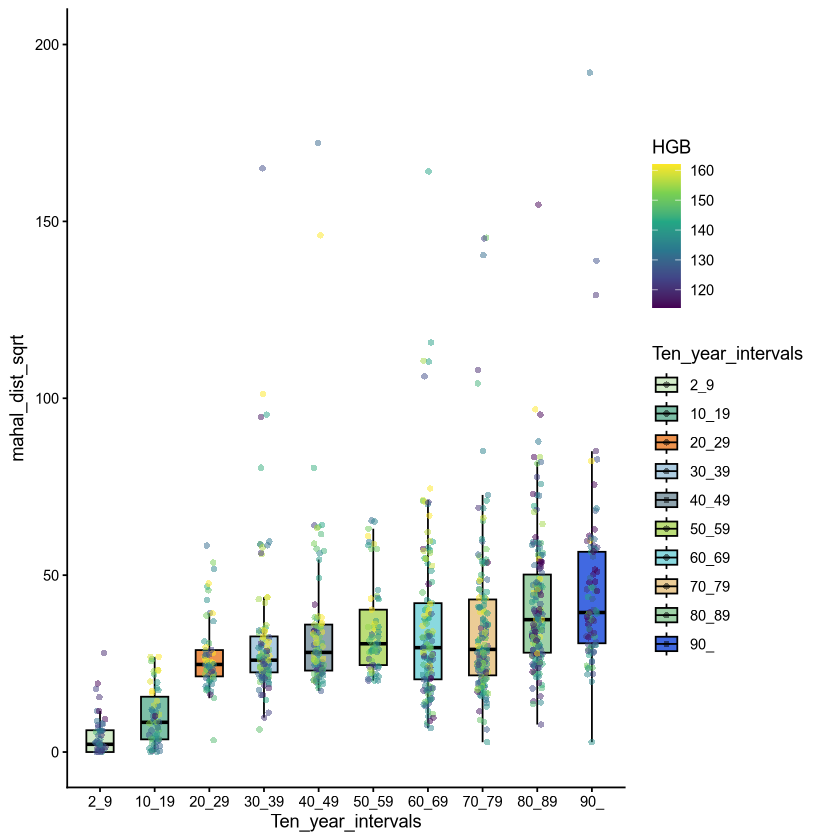

Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 8 rows containing missing values or values outside the scale range
(`geom_point()`).”


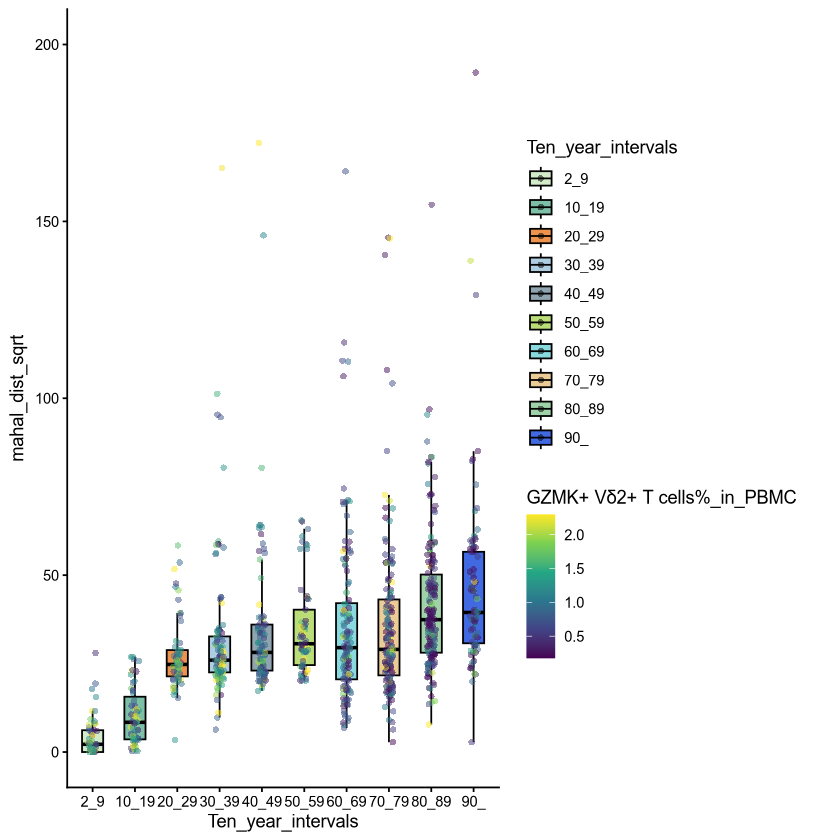

Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 11 rows containing missing values or values outside the scale range
(`geom_point()`).”


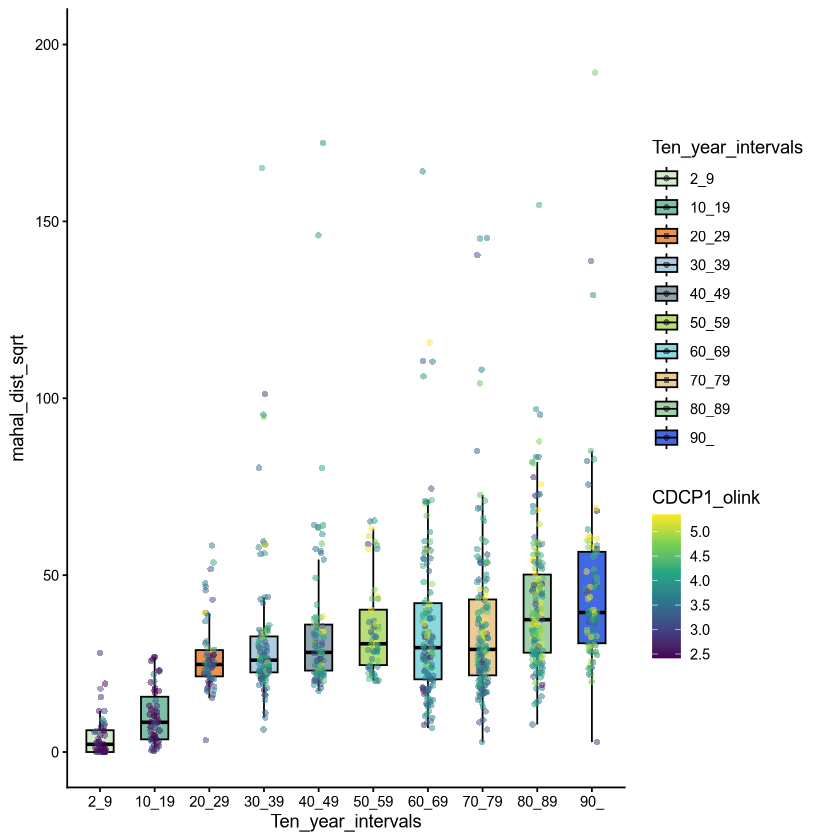

Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 6 rows containing missing values or values outside the scale range
(`geom_point()`).”


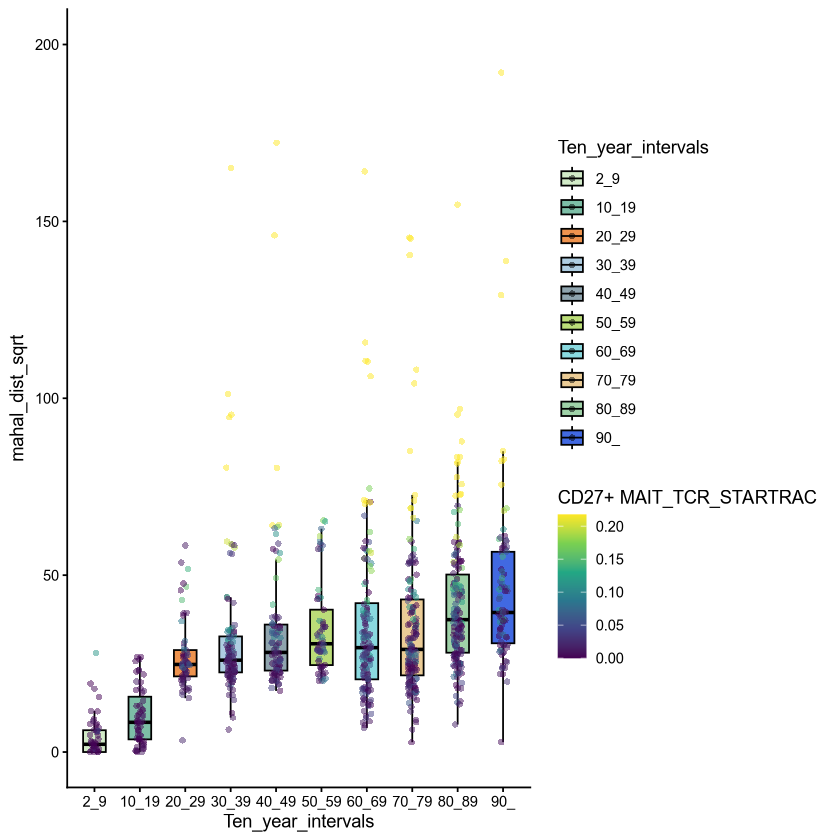

Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 10 rows containing missing values or values outside the scale range
(`geom_point()`).”


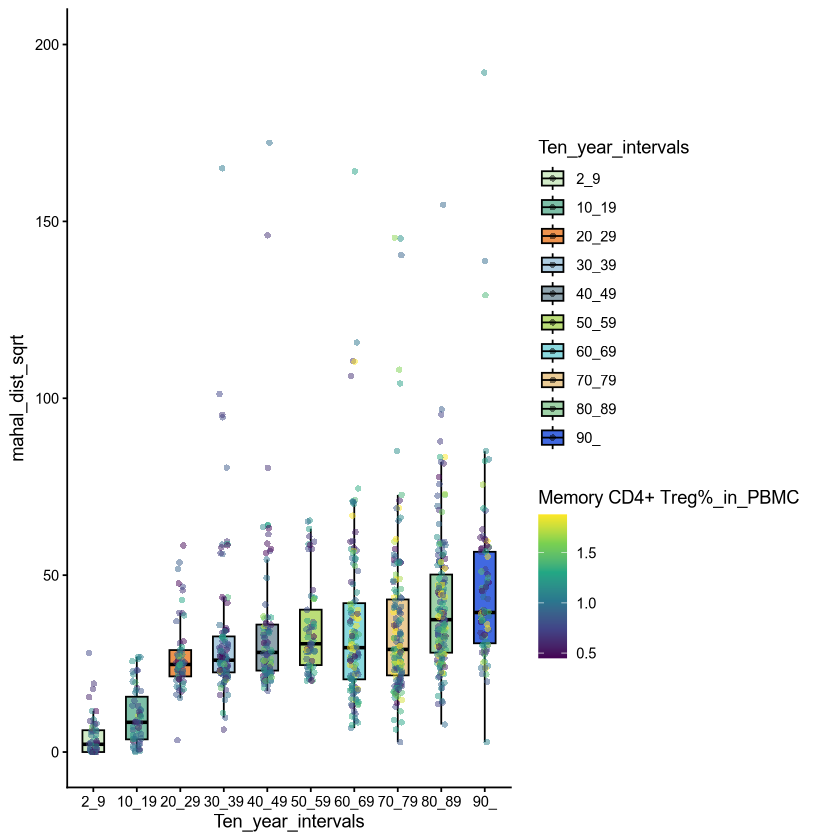

Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 12 rows containing missing values or values outside the scale range
(`geom_point()`).”


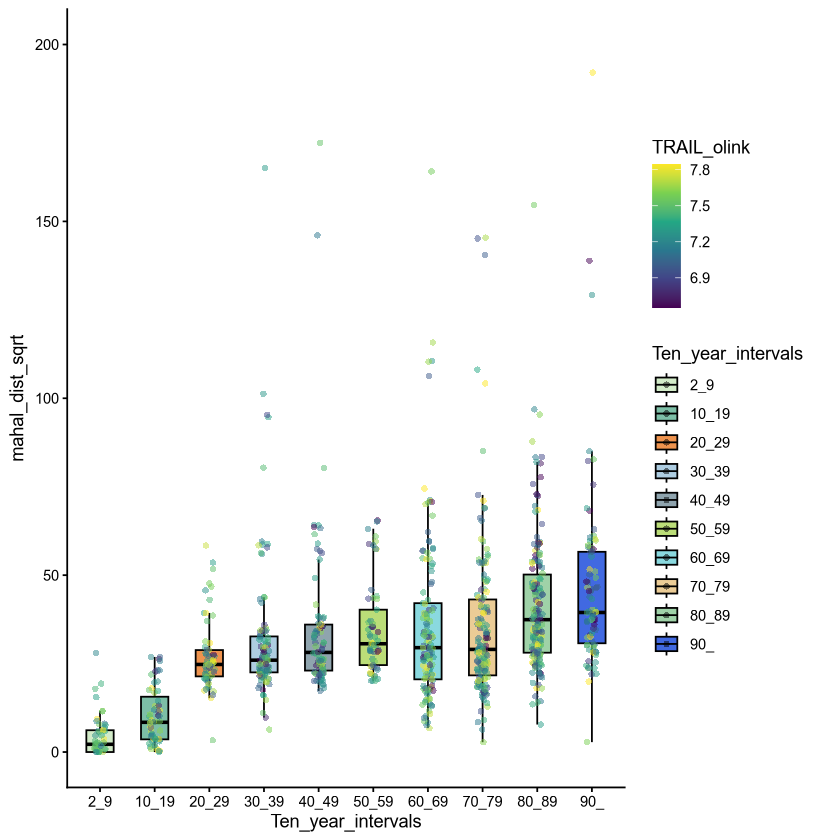

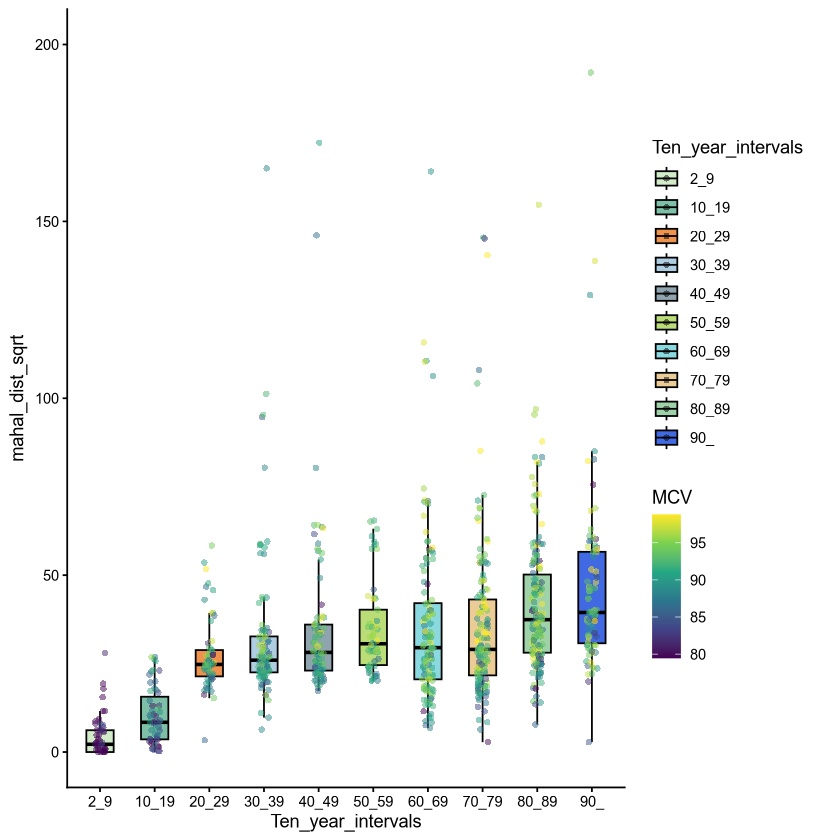

In [27]:
color_pal <- c('#D2EBC8','#7DBFA7','#EE934E','#AECDE1','#8FA4AE','#BBDD78','#8AD9DF','#EBCC96','#9FD2A8','#4169E1')

ggplot(all_dat_core,aes(y = mahal_dist_sqrt, x = Ten_year_intervals,fill = Ten_year_intervals))+
    geom_boxplot(width = 0.5, outlier.shape = NA, color = 'black')+
    geom_jitter(aes(color=`Naïve CD8+ T cells%_in_PBMC`),shape = 16, width = 0.1, size = 1.5, alpha = 0.5)+
    scale_color_viridis_c(
        limits = quantile(all_dat_core$`Naïve CD8+ T cells%_in_PBMC`, c(0.05, 0.95)),oob = scales::squish) +
    scale_fill_manual(values = color_pal)+
    theme_classic()+ylim(c(0,200))

ggplot(all_dat_core,aes(y = mahal_dist_sqrt, x = Ten_year_intervals,fill = Ten_year_intervals))+
    geom_boxplot(width = 0.5, outlier.shape = NA, color = 'black')+
    geom_jitter(aes(color=`PDW`),shape = 16, width = 0.1, size = 1.5, alpha = 0.5)+
    scale_color_viridis_c(
        limits = quantile(all_dat_core$`PDW`, c(0.05, 0.95)),oob = scales::squish) +
    scale_fill_manual(values = color_pal)+
    theme_classic()+ylim(c(0,200))
ggplot(all_dat_core,aes(y = mahal_dist_sqrt, x = Ten_year_intervals,fill = Ten_year_intervals))+
    geom_boxplot(width = 0.5, outlier.shape = NA, color = 'black')+
    geom_jitter(aes(color=`Naïve CD8+ T cells_TCR_shannon`),shape = 16, width = 0.1, size = 1.5, alpha = 0.5)+
    scale_color_viridis_c(
        limits = quantile(all_dat_core$`Naïve CD8+ T cells_TCR_shannon`, c(0.05, 0.95)),oob = scales::squish) +
    scale_fill_manual(values = color_pal)+
    theme_classic()+ylim(c(0,200))
ggplot(all_dat_core,aes(y = mahal_dist_sqrt, x = Ten_year_intervals,fill = Ten_year_intervals))+
    geom_boxplot(width = 0.5, outlier.shape = NA, color = 'black')+
    geom_jitter(aes(color=`KLRC2+ effector Vδ1+ T cells%_in_PBMC`),shape = 16, width = 0.1, size = 1.5, alpha = 0.5)+
    scale_color_viridis_c(
        limits = quantile(all_dat_core$`KLRC2+ effector Vδ1+ T cells%_in_PBMC`, c(0.05, 0.95)),oob = scales::squish) +
    scale_fill_manual(values = color_pal)+
    theme_classic()+ylim(c(0,200))
ggplot(all_dat_core,aes(y = mahal_dist_sqrt, x = Ten_year_intervals,fill = Ten_year_intervals))+
    geom_boxplot(width = 0.5, outlier.shape = NA, color = 'black')+
    geom_jitter(aes(color=`SOX4+ Vδ1+ T cells%_in_PBMC`),shape = 16, width = 0.1, size = 1.5, alpha = 0.5)+
    scale_color_viridis_c(
        limits = quantile(all_dat_core$`SOX4+ Vδ1+ T cells%_in_PBMC`, c(0.05, 0.95)),oob = scales::squish) +
    scale_fill_manual(values = color_pal)+
    theme_classic()+ylim(c(0,200))
ggplot(all_dat_core,aes(y = mahal_dist_sqrt, x = Ten_year_intervals,fill = Ten_year_intervals))+
    geom_boxplot(width = 0.5, outlier.shape = NA, color = 'black')+
    geom_jitter(aes(color=`Non-switched memory B cells_BCR_shannon`),shape = 16, width = 0.1, size = 1.5, alpha = 0.5)+
    scale_color_viridis_c(
        limits = quantile(all_dat_core$`Non-switched memory B cells_BCR_shannon`, c(0.05, 0.95)),oob = scales::squish) +
    scale_fill_manual(values = color_pal)+
    theme_classic()+ylim(c(0,200))
ggplot(all_dat_core,aes(y = mahal_dist_sqrt, x = Ten_year_intervals,fill = Ten_year_intervals))+
    geom_boxplot(width = 0.5, outlier.shape = NA, color = 'black')+
    geom_jitter(aes(color=`CXCL9_olink`),shape = 16, width = 0.1, size = 1.5, alpha = 0.5)+
    scale_color_viridis_c(
        limits = quantile(all_dat_core$`CXCL9_olink`, c(0.05, 0.95)),oob = scales::squish) +
    scale_fill_manual(values = color_pal)+
    theme_classic()+ylim(c(0,200))
ggplot(all_dat_core,aes(y = mahal_dist_sqrt, x = Ten_year_intervals,fill = Ten_year_intervals))+
    geom_boxplot(width = 0.5, outlier.shape = NA, color = 'black')+
    geom_jitter(aes(color=`CD279+ SOX4+ Vδ1+ T cells%_in_PBMC`),shape = 16, width = 0.1, size = 1.5, alpha = 0.5)+
    scale_color_viridis_c(
        limits = quantile(all_dat_core$`CD279+ SOX4+ Vδ1+ T cells%_in_PBMC`, c(0.05, 0.95)),oob = scales::squish) +
    scale_fill_manual(values = color_pal)+
    theme_classic()+ylim(c(0,200))
ggplot(all_dat_core,aes(y = mahal_dist_sqrt, x = Ten_year_intervals,fill = Ten_year_intervals))+
    geom_boxplot(width = 0.5, outlier.shape = NA, color = 'black')+
    geom_jitter(aes(color=`GZMK+ effector Vδ1+ T cells%_in_PBMC`),shape = 16, width = 0.1, size = 1.5, alpha = 0.5)+
    scale_color_viridis_c(
        limits = quantile(all_dat_core$`GZMK+ effector Vδ1+ T cells%_in_PBMC`, c(0.05, 0.95)),oob = scales::squish) +
    scale_fill_manual(values = color_pal)+
    theme_classic()+ylim(c(0,200))


ggplot(all_dat_core,aes(y = mahal_dist_sqrt, x = Ten_year_intervals,fill = Ten_year_intervals))+
    geom_boxplot(width = 0.5, outlier.shape = NA, color = 'black')+
    geom_jitter(aes(color=`TRANCE_olink`),shape = 16, width = 0.1, size = 1.5, alpha = 0.5)+
    scale_color_viridis_c(
        limits = quantile(all_dat_core$`TRANCE_olink`, c(0.05, 0.95)),oob = scales::squish) +
    scale_fill_manual(values = color_pal)+
    theme_classic()+ylim(c(0,200))
ggplot(all_dat_core,aes(y = mahal_dist_sqrt, x = Ten_year_intervals,fill = Ten_year_intervals))+
    geom_boxplot(width = 0.5, outlier.shape = NA, color = 'black')+
    geom_jitter(aes(color=`OPG_olink`),shape = 16, width = 0.1, size = 1.5, alpha = 0.5)+
    scale_color_viridis_c(
        limits = quantile(all_dat_core$`OPG_olink`, c(0.05, 0.95)),oob = scales::squish) +
    scale_fill_manual(values = color_pal)+
    theme_classic()+ylim(c(0,200))

ggplot(all_dat_core,aes(y = mahal_dist_sqrt, x = Ten_year_intervals,fill = Ten_year_intervals))+
    geom_boxplot(width = 0.5, outlier.shape = NA, color = 'black')+
    geom_jitter(aes(color=`CXCL8- PTGS2+ NDNs%_in_NDN_BAS`),shape = 16, width = 0.1, size = 1.5, alpha = 0.5)+
    scale_color_viridis_c(
        limits = quantile(all_dat_core$`CXCL8- PTGS2+ NDNs%_in_NDN_BAS`, c(0.05, 0.95)),oob = scales::squish) +
    scale_fill_manual(values = color_pal)+
    theme_classic()+ylim(c(0,200))

ggplot(all_dat_core,aes(y = mahal_dist_sqrt, x = Ten_year_intervals,fill = Ten_year_intervals))+
    geom_boxplot(width = 0.5, outlier.shape = NA, color = 'black')+
    geom_jitter(aes(color=`MCH`),shape = 16, width = 0.1, size = 1.5, alpha = 0.5)+
    scale_color_viridis_c(
        limits = quantile(all_dat_core$`MCH`, c(0.05, 0.95)),oob = scales::squish) +
    scale_fill_manual(values = color_pal)+
    theme_classic()+ylim(c(0,200))
ggplot(all_dat_core,aes(y = mahal_dist_sqrt, x = Ten_year_intervals,fill = Ten_year_intervals))+
    geom_boxplot(width = 0.5, outlier.shape = NA, color = 'black')+
    geom_jitter(aes(color=`HGB`),shape = 16, width = 0.1, size = 1.5, alpha = 0.5)+
    scale_color_viridis_c(
        limits = quantile(all_dat_core$`HGB`, c(0.05, 0.95)),oob = scales::squish) +
    scale_fill_manual(values = color_pal)+
    theme_classic()+ylim(c(0,200))
ggplot(all_dat_core,aes(y = mahal_dist_sqrt, x = Ten_year_intervals,fill = Ten_year_intervals))+
    geom_boxplot(width = 0.5, outlier.shape = NA, color = 'black')+
    geom_jitter(aes(color=`GZMK+ Vδ2+ T cells%_in_PBMC`),shape = 16, width = 0.1, size = 1.5, alpha = 0.5)+
    scale_color_viridis_c(
        limits = quantile(all_dat_core$`GZMK+ Vδ2+ T cells%_in_PBMC`, c(0.05, 0.95)),oob = scales::squish) +
    scale_fill_manual(values = color_pal)+
    theme_classic()+ylim(c(0,200))

ggplot(all_dat_core,aes(y = mahal_dist_sqrt, x = Ten_year_intervals,fill = Ten_year_intervals))+
    geom_boxplot(width = 0.5, outlier.shape = NA, color = 'black')+
    geom_jitter(aes(color=`CDCP1_olink`),shape = 16, width = 0.1, size = 1.5, alpha = 0.5)+
    scale_color_viridis_c(
        limits = quantile(all_dat_core$`CDCP1_olink`, c(0.05, 0.95)),oob = scales::squish) +
    scale_fill_manual(values = color_pal)+
    theme_classic()+ylim(c(0,200))

ggplot(all_dat_core,aes(y = mahal_dist_sqrt, x = Ten_year_intervals,fill = Ten_year_intervals))+
    geom_boxplot(width = 0.5, outlier.shape = NA, color = 'black')+
    geom_jitter(aes(color=`CD27+ MAIT_TCR_STARTRAC`),shape = 16, width = 0.1, size = 1.5, alpha = 0.5)+
    scale_color_viridis_c(
        limits = quantile(all_dat_core$`CD27+ MAIT_TCR_STARTRAC`, c(0.05, 0.95)),oob = scales::squish) +
    scale_fill_manual(values = color_pal)+
    theme_classic()+ylim(c(0,200))


ggplot(all_dat_core,aes(y = mahal_dist_sqrt, x = Ten_year_intervals,fill = Ten_year_intervals))+
    geom_boxplot(width = 0.5, outlier.shape = NA, color = 'black')+
    geom_jitter(aes(color=`Memory CD4+ Treg%_in_PBMC`),shape = 16, width = 0.1, size = 1.5, alpha = 0.5)+
    scale_color_viridis_c(
        limits = quantile(all_dat_core$`Memory CD4+ Treg%_in_PBMC`, c(0.05, 0.95)),oob = scales::squish) +
    scale_fill_manual(values = color_pal)+
    theme_classic()+ylim(c(0,200))


ggplot(all_dat_core,aes(y = mahal_dist_sqrt, x = Ten_year_intervals,fill = Ten_year_intervals))+
    geom_boxplot(width = 0.5, outlier.shape = NA, color = 'black')+
    geom_jitter(aes(color=`TRAIL_olink`),shape = 16, width = 0.1, size = 1.5, alpha = 0.5)+
    scale_color_viridis_c(
        limits = quantile(all_dat_core$`TRAIL_olink`, c(0.05, 0.95)),oob = scales::squish) +
    scale_fill_manual(values = color_pal)+
    theme_classic()+ylim(c(0,200))


ggplot(all_dat_core,aes(y = mahal_dist_sqrt, x = Ten_year_intervals,fill = Ten_year_intervals))+
    geom_boxplot(width = 0.5, outlier.shape = NA, color = 'black')+
    geom_jitter(aes(color=`MCV`),shape = 16, width = 0.1, size = 1.5, alpha = 0.5)+
    scale_color_viridis_c(
        limits = quantile(all_dat_core$`MCV`, c(0.05, 0.95)),oob = scales::squish) +
    scale_fill_manual(values = color_pal)+
    theme_classic()+ylim(c(0,200))

Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 11 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 8 rows containing missing values or values outside the scale range
(`geom_point()`).”


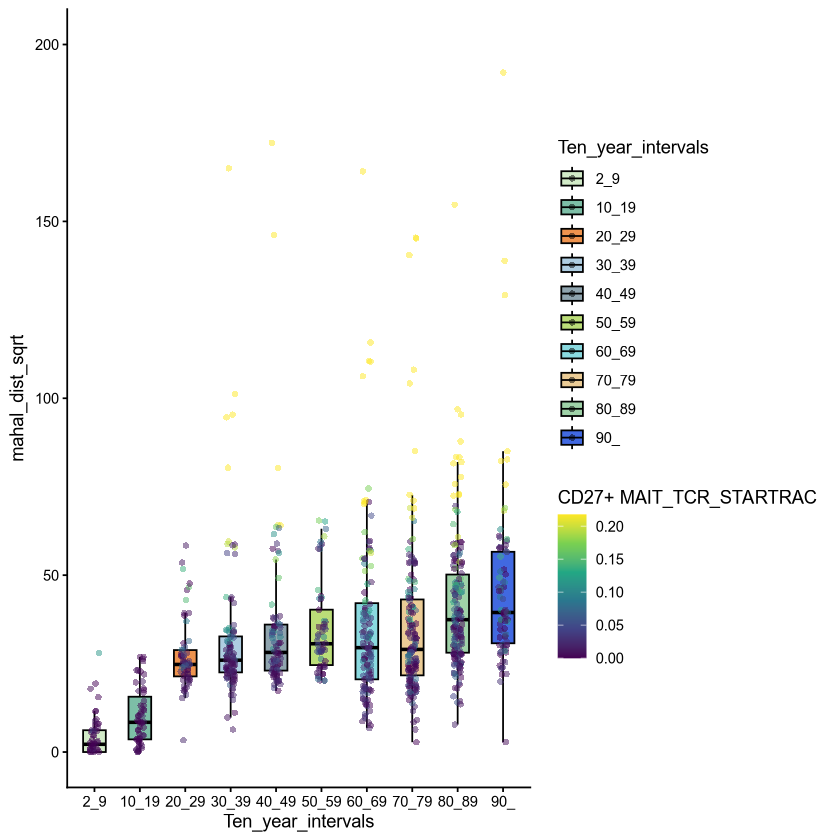

In [28]:
p1 = ggplot(all_dat_core,aes(y = mahal_dist_sqrt, x = Ten_year_intervals,fill = Ten_year_intervals))+
    geom_boxplot(width = 0.5, outlier.shape = NA, color = 'black')+
    geom_jitter(aes(color=`CD27+ MAIT_TCR_STARTRAC`),shape = 16, width = 0.1, size = 1.5, alpha = 0.5)+
    scale_color_viridis_c(
        limits = quantile(all_dat_core$`CD27+ MAIT_TCR_STARTRAC`, c(0.05, 0.95)),oob = scales::squish) +
    scale_fill_manual(values = color_pal)+
    theme_classic()+ylim(c(0,200))
p1
ggsave('../13_Multimodal/Ten_year_intervals_CD27+ MAIT_TCR_STARTRAC_mahal_dist_sqrt_top20.pdf',p1,width=6,height = 4)

Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 13 rows containing missing values or values outside the scale range
(`geom_point()`).”


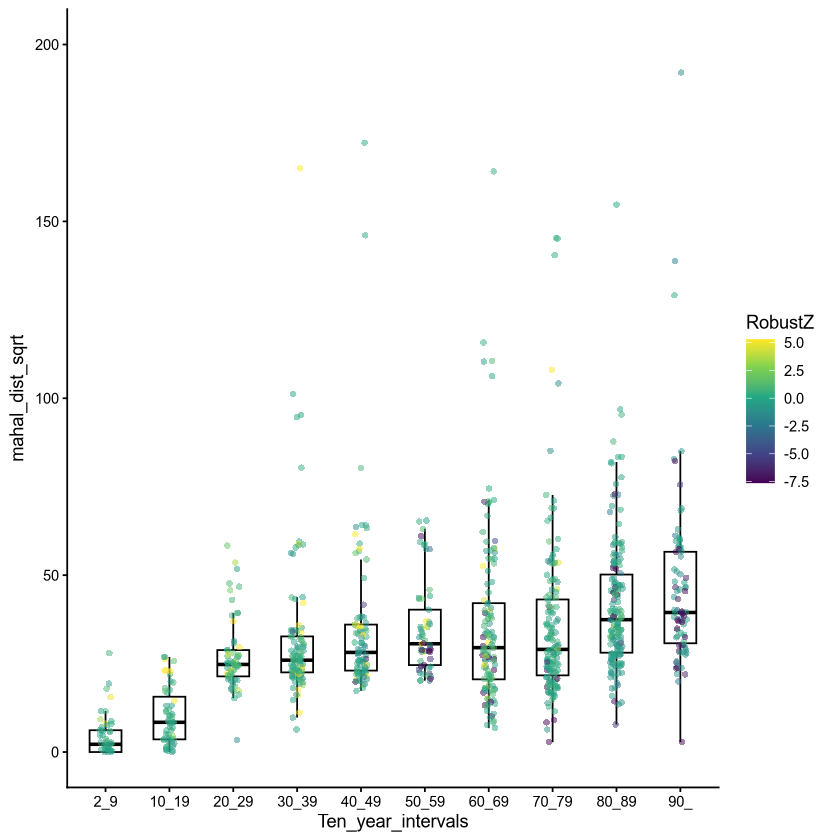

In [29]:
color_pal <- c('#D2EBC8','#7DBFA7','#EE934E','#AECDE1','#8FA4AE','#BBDD78','#8AD9DF','#EBCC96','#9FD2A8','#4169E1')

ggplot(na.omit(all_dat_core),aes(y = mahal_dist_sqrt, x = Ten_year_intervals))+
    geom_boxplot(width = 0.5, outlier.shape = NA, color = 'black')+
    geom_jitter(aes(color=RobustZ),shape = 16, width = 0.1, size = 1.5, alpha = 0.5)+
    scale_color_viridis_c(
        limits = quantile(all_dat_core$RobustZ, c(0.05, 0.95)),
        oob = scales::squish) +
    scale_fill_manual(values = color_pal)+
    theme_classic()+ylim(c(0,200))

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


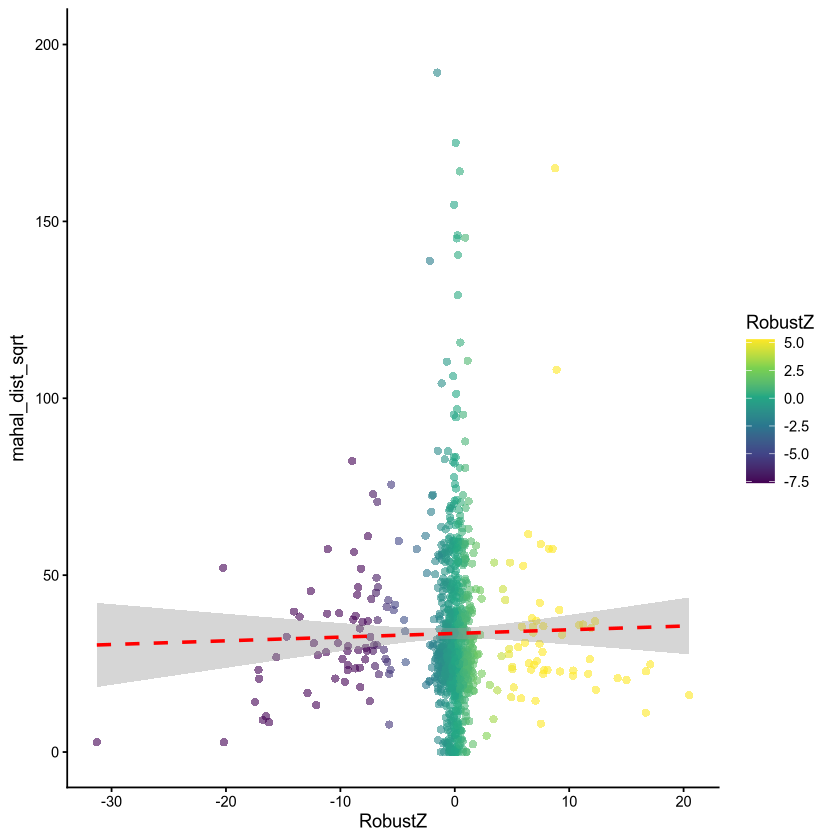

In [30]:
p3 <- ggplot(all_dat_core, aes(x=RobustZ, y=mahal_dist_sqrt)) +
  geom_point(aes(color=RobustZ), alpha=0.6, size=2,shape=16) +
  geom_smooth(method="lm", color="red", linetype="dashed") +
  scale_color_viridis_c(limits = quantile(all_dat_core$RobustZ, c(0.05, 0.95)),
        oob = scales::squish) +
  theme_classic()+ylim(c(0,200))
p3
ggsave('../13_Multimodal/RobustZ_mahal_dist_sqrt.pdf',p3,width=6,height = 6)

In [36]:
write.csv(all_dat_core,'../13_Multimodal/all_dat_core.csv')